# DL Final Project -- MLP for YouTube View Count Prediction

## Goal

Build a MLP to predict **log(1 + view_count)** of YouTube videos.

## Input Features (8)

1. `subscriber_count` — 頻道總訂閱數
2. `video_duration_sec` — 影片長度（秒）
3. `categoryId` — 影片分類 ID（已移除 10，並 One-hot 編碼）
4. `published_at` — 發布時間（已轉換為小時與星期幾的週期性編碼 features）
5. `tags_count` — tags 數量
6. `description_length` — description 字元長度
7. `channel_view_count` — 頻道總觀看數
8. `channel_video_count` — 頻道影片數

## Target

- `log(1 + view_count)`

## Settings

- Train / Test split: 70% / 15% / 15% (Train/Val/Test)
- Epochs: 200
- Batch size: 64

## Part 1

Clone the dataset from GitHub and import necessary libraries.

In [7]:
!git clone https://github.com/yitingCurry/DL_Data_New.git

fatal: destination path 'DL_Data_New' already exists and is not an empty directory.


## Part 2

Import libraries.

In [8]:
# Model
import os
import copy
import torch
import torch.nn as nn
from torch.optim.optimizer import Optimizer

# Dataset
from torch.utils.data import Dataset, DataLoader

# Pre-processing
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime, timezone
from sklearn.model_selection import train_test_split

## Part 3

Global variables / hyperparameters.

In [9]:
batch_size = 64
num_epoch = 200
learning_rate = 0.0005
train_ratio = 0.85      # 85% for train+val pool, remaining 15% for test
val_ratio = 15 / 85     # From train+val pool, 15/85 (approx 17.65%) will be validation, resulting in 15% of total data for validation
seed = 42

LOSS_TYPE = 'huber'   # 'huber' or 'mse'
HUBER_BETA = 0.5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Part 4

Data loading and preprocessing.

- Parse ISO 8601 duration → seconds
- Parse `published_at` → hour of day + day of week (cyclic encoding)
- Remove rows where `categoryId == 10`
- Fill missing values (tag_count → 0, description_length → 0)
- StandardScaler normalization on all features
- Target: `log(1 + view_count)`

In [10]:
# ── 工具函式 ────────────────────────────────────────────────

def parse_iso8601_duration(duration_str):
    """ISO 8601 duration (e.g. PT1H2M3S) → seconds (int)"""
    if not isinstance(duration_str, str):
        return 0
    pattern = r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
    match = re.match(pattern, duration_str)
    if not match:
        return 0
    h = int(match.group(1) or 0)
    m = int(match.group(2) or 0)
    s = int(match.group(3) or 0)
    return h * 3600 + m * 60 + s


def parse_published_at(dt_str):
    """ISO 8601 datetime → (hour_of_day, day_of_week)"""
    try:
        dt = datetime.fromisoformat(dt_str.replace('Z', '+00:00'))
        return dt.hour, dt.weekday()   # 0-23, 0-6
    except Exception:
        return 0, 0


class StandardScaler:
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_  = X.std(axis=0) + 1e-8
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_


# ── 讀取資料 ────────────────────────────────────────────────
# data_dir = 'DL_Data/data'
# files = os.listdir(data_dir)

# csv_files  = [f for f in files if f.endswith('.csv')]
# json_files = [f for f in files if f.endswith('.json')]

# if csv_files:
#     df = pd.read_csv(os.path.join(data_dir, csv_files[0]))
# elif json_files:
#     df = pd.read_json(os.path.join(data_dir, json_files[0]))
# else:
#     raise FileNotFoundError('找不到資料檔')
file_path = 'DL_Data_New/tw_youtube_videos.jsonl'
df = pd.read_json(file_path, lines=True)
print(f'Loaded data shape={df.shape}')

Loaded data shape=(12046, 29)


In [11]:
# ── 特徵工程 (優化版) ────────────────────────────────────────────────

# # 1. 移除 category_id == 10
if 'category_id' in df.columns:
    df = df[df['category_id'] != 10].copy()

# 2. 處理類別型特徵：One-hot Encoding for category_id
df['category_id'] = df['category_id'].astype(str)
df_encoded = pd.get_dummies(df, columns=['category_id'], prefix='cat')

# 3. 數值特徵轉換
if 'duration_iso8601' in df.columns:
    df_encoded['video_duration_sec'] = df['duration_iso8601'].apply(parse_iso8601_duration)

if 'published_at' in df.columns:
    df_encoded[['pub_hour', 'pub_weekday']] = df['published_at'].apply(
        lambda x: pd.Series(parse_published_at(str(x)))
    )

    # 週期性編碼 (Cyclic Encoding) for pub_hour and pub_weekday
    # pub_hour (0-23)
    df_encoded['pub_hour_sin'] = np.sin(2 * np.pi * df_encoded['pub_hour'] / 24.0)
    df_encoded['pub_hour_cos'] = np.cos(2 * np.pi * df_encoded['pub_hour'] / 24.0)
    # pub_weekday (0-6, Mon-Sun)
    df_encoded['pub_weekday_sin'] = np.sin(2 * np.pi * df_encoded['pub_weekday'] / 7.0)
    df_encoded['pub_weekday_cos'] = np.cos(2 * np.pi * df_encoded['pub_weekday'] / 7.0)

    # 確保數值型欄位為數值，並處理潛在的非數值資料
for col in ['subscriber_count', 'description_length', 'channel_view_count', 'channel_video_count', 'tags_count']:
    if col in df_encoded.columns:
        df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce').fillna(0)


#subscriber_count太大，要壓縮
df_encoded['subscriber_count'] = np.log1p(df_encoded['subscriber_count'])
df_encoded['video_duration_sec'] = np.log1p(df_encoded['video_duration_sec'])
df_encoded['description_length'] = np.log1p(df_encoded['description_length'])
df_encoded['channel_view_count'] = np.log1p(df_encoded['channel_view_count'])
df_encoded['channel_video_count'] = np.log1p(df_encoded['channel_video_count'])



# 4. 建立特徵清單 (包含 One-hot 後的欄位)
CAT_COLS = [col for col in df_encoded.columns if col.startswith('cat_')]
NUM_COLS = ['subscriber_count', 'video_duration_sec', 'tags_count', 'description_length',
            'pub_hour_sin', 'pub_hour_cos', 'pub_weekday_sin', 'pub_weekday_cos',
            'channel_view_count','channel_video_count']
FEATURE_COLS = CAT_COLS + NUM_COLS

X = df_encoded[FEATURE_COLS].values.astype(np.float32)
input_dim = X.shape[1] # 更新輸入維度

# target: log(1 + view_count)
view_col = 'view_count' if 'view_count' in df.columns else 'viewCount'
y = np.log1p(df[view_col].values.astype(np.float32))


print(f'New Feature matrix shape: {X.shape} (One-hot and Cyclic Encoding included)')
print(f'Target range: [{y.min():.2f}, {y.max():.2f}]')
display(df_encoded[FEATURE_COLS].head(10))

New Feature matrix shape: (10254, 24) (One-hot and Cyclic Encoding included)
Target range: [0.00, 20.70]


,cat_1,cat_15,cat_17,cat_19,cat_2,cat_20,cat_22,cat_23,cat_24,cat_25,...,subscriber_count,video_duration_sec,tags_count,description_length,pub_hour_sin,pub_hour_cos,pub_weekday_sin,pub_weekday_cos,channel_view_count,channel_video_count
0,False,False,False,False,False,True,False,False,False,False,...,12.955130,6.206576,28,6.349139,7.071068e-01,0.707107,0.781831,0.623490,19.447769,8.155936
1,False,False,False,False,True,False,False,False,False,False,...,0.000000,6.948897,22,7.614805,-7.071068e-01,-0.707107,0.433884,-0.900969,0.000000,0.000000
3,False,False,False,False,False,False,False,False,False,False,...,0.000000,3.951244,0,6.056784,0.000000e+00,1.000000,-0.433884,-0.900969,0.000000,0.000000
4,False,False,False,False,False,True,False,False,False,False,...,11.911708,6.284134,60,5.913503,7.071068e-01,-0.707107,-0.974928,-0.222521,17.350076,6.291569
5,False,False,False,False,True,False,False,False,False,False,...,0.000000,7.542744,83,7.485492,1.224647e-16,-1.000000,0.974928,-0.222521,0.000000,0.000000
6,False,False,False,False,False,False,True,False,False,False,...,10.943782,2.890372,0,6.300786,7.071068e-01,-0.707107,0.000000,1.000000,17.170504,6.139885
7,False,False,False,False,False,True,False,False,False,False,...,0.000000,2.564949,1,0.000000,8.660254e-01,0.500000,-0.974928,-0.222521,0.000000,0.000000
8,False,False,False,False,False,False,False,False,True,False,...,0.000000,7.032624,48,5.743003,1.224647e-16,-1.000000,-0.781831,0.623490,0.000000,0.000000
9,False,False,False,False,False,False,False,False,True,False,...,11.248973,6.234411,33,6.516193,5.000000e-01,-0.866025,-0.433884,-0.900969,17.199509,5.693732
10,False,False,False,False,False,False,True,False,False,False,...,0.000000,6.177944,0,3.828641,5.000000e-01,0.866025,-0.974928,-0.222521,0.000000,0.000000


## Part 5

建立 Dataset 和 DataLoader，並依據 `DL_Data_New/data_split.json` 檔案中預先定義的 `video_id` 列表進行訓練/驗證/測試集切分。

- 訓練集、驗證集、測試集的 `video_id` 列表已從 `DL_Data_New/data_split.json` 載入。
- 屬於同一個 `video_id` 的所有資料記錄，將會被分配到同一個切分集（訓練、驗證或測試）。
- 目標變數 `log(1 + view_count)` 的分布特性由預先定義的切分決定。

In [12]:
class YouTubeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # 確保目標變數為浮點數且維度正確

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


np.random.seed(seed)
torch.manual_seed(seed)

# --- 依據 DL_Data_New/data_split.json 進行資料切分 (Train/Val/Test) ---
import json

with open('DL_Data_New/data_split.json', 'r') as f:
    data_split_ids = json.load(f)

train_video_ids = data_split_ids['train']
val_video_ids = data_split_ids['val']
test_video_ids = data_split_ids['test']

# 根據 video_id 過濾 df_encoded 和 y
# 確保 df_encoded 包含 'video_id' 欄位
train_df = df_encoded[df_encoded['video_id'].isin(train_video_ids)]
val_df = df_encoded[df_encoded['video_id'].isin(val_video_ids)]
test_df = df_encoded[df_encoded['video_id'].isin(test_video_ids)]

# 獲取對應的 X 和 y 陣列
# train_indices, val_indices, test_indices 現在是原始的 DataFrame 索引
train_indices = train_df.index
val_indices = val_df.index
test_indices = test_df.index

# 獲取 df_encoded 的完整索引，用於將原始 DataFrame 索引映射到 NumPy 陣列的位置索引
original_df_indices = df_encoded.index

# 將原始 DataFrame 索引轉換為 NumPy 陣列的 0-based 位置索引
train_pos_indices = original_df_indices.get_indexer(train_indices)
val_pos_indices = original_df_indices.get_indexer(val_indices)
test_pos_indices = original_df_indices.get_indexer(test_indices)

# 使用位置索引來切分 X 和 y (它們是 NumPy 陣列)
X_train, y_train = X[train_pos_indices], y[train_pos_indices]
X_val, y_val = X[val_pos_indices], y[val_pos_indices]
X_test, y_test = X[test_pos_indices], y[test_pos_indices]

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

train_dataset = YouTubeDataset(X_train, y_train)
val_dataset = YouTubeDataset(X_val, y_val)
test_dataset = YouTubeDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train samples: {len(X_train)} | Val samples: {len(X_val)} | Test samples: {len(X_test)}')
print(f'Train target mean/std: {y_train.mean():.3f}/{y_train.std():.3f}')
print(f'Val   target mean/std: {y_val.mean():.3f}/{y_val.std():.3f}')
print(f'Test  target mean/std: {y_test.mean():.3f}/{y_test.std():.3f}')

Train samples: 7175 | Val samples: 1538 | Test samples: 1538
Train target mean/std: 10.815/2.878
Val   target mean/std: 10.827/2.955
Test  target mean/std: 10.838/2.922


## Part 6

Activation function — ReLU (custom implementation).

In [13]:
class myActivation(nn.Module):

    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU()

    def forward(self, x):
        # ReLU: max(0, x)
        return self.relu(x)

## Part 7

MLP model architecture.

- Input: 6 features
- Hidden layers: 512 → 256 → 128 → 64
- Output: 1 (regression, log view count)
- Activation: ReLU
- BatchNorm for stable training
- Dropout to prevent overfitting

In [14]:
class myMLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super(myMLP, self).__init__()
        self.mlp = nn.Sequential(

            #Model_E [256, 256, 128, 128, 64] | lr=0.0001 wd=0.001 dr=0.3
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            myActivation(),
            nn.Dropout(dropout_rate), # 輕微降低 Dropout 防止過擬合

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            myActivation(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            myActivation(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            myActivation(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            myActivation(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.mlp(x)

model = myMLP(input_dim).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 131,585


## Part 8

Loss function for regression.

- `LOSS_TYPE='huber'`: SmoothL1/Huber（對長尾與離群值較穩）
- `LOSS_TYPE='mse'`: 與原始版本一致

In [15]:
class myLoss(nn.Module):
    def __init__(self, loss_type='huber', beta=0.5):
        super().__init__()
        self.loss_type = loss_type
        self.huber = nn.SmoothL1Loss(beta=beta)
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        if self.loss_type == 'huber':
            return self.huber(pred, target)
        return self.mse(pred, target)


criterion = myLoss(loss_type=LOSS_TYPE, beta=HUBER_BETA)
print(f'Using loss: {LOSS_TYPE}')

Using loss: huber


## Part 9

Optimizer — SGD with momentum and weight decay.

In [16]:
# 將 Optimizer 更換為 Adam
import torch.optim as optim

# 使用 Adam 優化器，通常收斂速度較快且穩定
# 增加 weight_decay (L2 regularization) 防止過度擬合
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)

## Part 10

Model training（每個 epoch 監控 validation RMSE，儲存最佳 checkpoint）。

In [17]:
def eval_regression(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y_batch in loader:
            x = x.to(device).float()
            y_batch = y_batch.to(device).float()
            output = model(x)
            preds.append(output.cpu())
            labels.append(y_batch.cpu())

    preds = torch.cat(preds, dim=0).squeeze()
    labels = torch.cat(labels, dim=0).squeeze()

    mse = torch.mean((preds - labels) ** 2).item()
    mae = torch.mean(torch.abs(preds - labels)).item()
    rmse = mse ** 0.5
    return mse, mae, rmse


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=12
)

best_val_rmse = float('inf')
best_epoch = -1
best_state = None

for epoch in range(num_epoch):
    model.train()
    losses = []

    for x, y_batch in train_loader:
        optimizer.zero_grad()
        x = x.to(device).float()
        y_batch = y_batch.to(device).float()

        output = model(x)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())

    train_loss = sum(losses) / len(losses)
    val_mse, val_mae, val_rmse = eval_regression(model, val_loader)
    scheduler.step(val_rmse)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f'Epoch {epoch + 1:3d}/{num_epoch} | '
            f'TrainLoss {train_loss:.4f} | Val RMSE {val_rmse:.4f} | Val MAE {val_mae:.4f}'
        )

model.load_state_dict(best_state)
torch.save(model.state_dict(), 'best_mlp_reg_model_state_dict.pt')
print(f'\nLoaded best epoch {best_epoch} | best Val RMSE {best_val_rmse:.4f}')
print('Model state dict saved as best_mlp_reg_model_state_dict.pt')

Epoch   1/200 | TrainLoss 9.3446 | Val RMSE 9.8829 | Val MAE 9.4348
Epoch  10/200 | TrainLoss 1.7091 | Val RMSE 2.6474 | Val MAE 1.8951
Epoch  20/200 | TrainLoss 1.6216 | Val RMSE 2.5394 | Val MAE 1.8101
Epoch  30/200 | TrainLoss 1.5862 | Val RMSE 2.4861 | Val MAE 1.7929
Epoch  40/200 | TrainLoss 1.5376 | Val RMSE 2.5028 | Val MAE 1.7807
Epoch  50/200 | TrainLoss 1.5039 | Val RMSE 2.6021 | Val MAE 1.7954
Epoch  60/200 | TrainLoss 1.4741 | Val RMSE 2.5192 | Val MAE 1.7683
Epoch  70/200 | TrainLoss 1.4452 | Val RMSE 2.4871 | Val MAE 1.7438
Epoch  80/200 | TrainLoss 1.4511 | Val RMSE 2.5164 | Val MAE 1.7427
Epoch  90/200 | TrainLoss 1.4236 | Val RMSE 2.4702 | Val MAE 1.7217
Epoch 100/200 | TrainLoss 1.4213 | Val RMSE 2.4509 | Val MAE 1.6989
Epoch 110/200 | TrainLoss 1.3920 | Val RMSE 2.4420 | Val MAE 1.7039
Epoch 120/200 | TrainLoss 1.3864 | Val RMSE 2.4612 | Val MAE 1.7221
Epoch 130/200 | TrainLoss 1.3787 | Val RMSE 2.4714 | Val MAE 1.7100
Epoch 140/200 | TrainLoss 1.3420 | Val RMSE 2.43

## Part 11

Model evaluation on test set（載入 validation RMSE 最佳模型）。

Metrics:
- MSE / MAE / RMSE on log scale
- RMSE / MAE on original scale（`expm1` 還原）

In [18]:
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y_batch in test_loader:
        x = x.to(device).float()
        y_batch = y_batch.to(device).float()
        output = model(x)
        all_preds.append(output.cpu())
        all_labels.append(y_batch.cpu())

all_preds = torch.cat(all_preds, dim=0).squeeze()
all_labels = torch.cat(all_labels, dim=0).squeeze()

# log scale metrics
test_mse_log = torch.mean((all_preds - all_labels) ** 2).item()
test_mae_log = torch.mean(torch.abs(all_preds - all_labels)).item()
test_rmse_log = test_mse_log ** 0.5

# original scale metrics (inverse log1p)
preds_org = torch.expm1(all_preds)
labels_org = torch.expm1(all_labels)
test_mse_org = torch.mean((preds_org - labels_org) ** 2).item()
test_mae_org = torch.mean(torch.abs(preds_org - labels_org)).item()
test_rmse_org = test_mse_org ** 0.5

print('=' * 60)
print('Test metrics (log1p scale):')
print(f'  MSE : {test_mse_log:.4f}')
print(f'  MAE : {test_mae_log:.4f}')
print(f'  RMSE: {test_rmse_log:.4f}')
print('-' * 60)
print('Test metrics (original view_count scale):')
print(f'  MAE : {test_mae_org:.2f}')
print(f'  RMSE: {test_rmse_org:.2f}')
print('=' * 60)

Test metrics (log1p scale):
  MSE : 5.9042
  MAE : 1.6404
  RMSE: 2.4298
------------------------------------------------------------
Test metrics (original view_count scale):
  MAE : 2942716.75
  RMSE: 24442680.86


## Part 12

Visualize predictions vs ground truth.

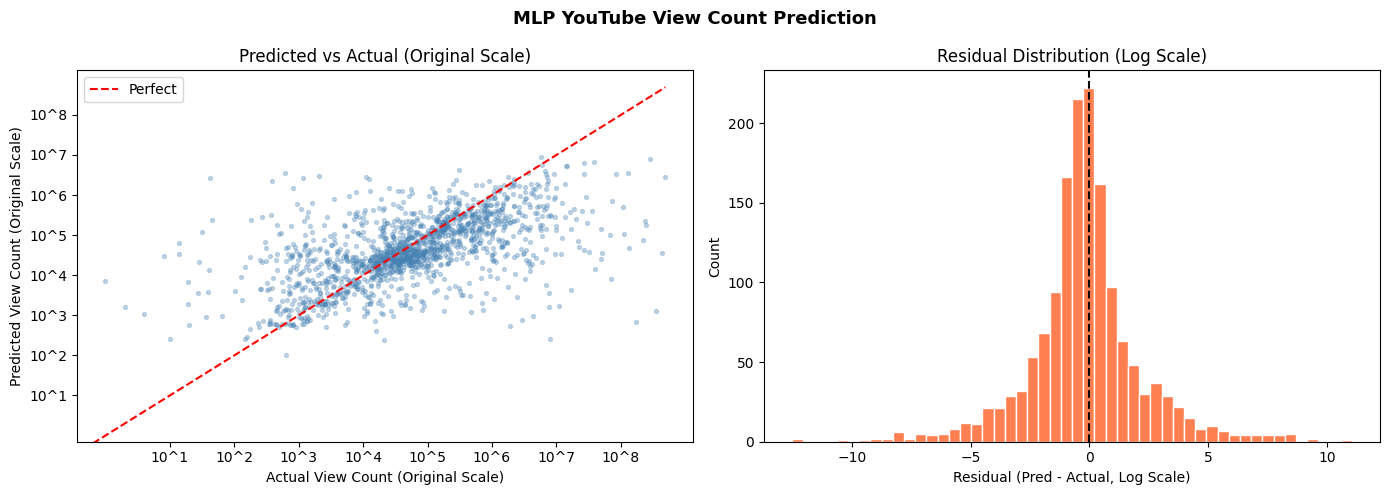

Plot saved as prediction_analysis.png


In [19]:
import matplotlib.pyplot as plt

# Use original scale predictions and labels
preds_np = preds_org.numpy()
labels_np = labels_org.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(labels_np, preds_np, alpha=0.3, s=8, color='steelblue')

# Set log scale for both axes with base 10
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# Define tick marks for powers of 10
ticks = [10**i for i in range(1, int(np.log10(max(labels_np.max(), preds_np.max()))) + 1)]
axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)
axes[0].set_xticklabels([f'10^{int(np.log10(t))}' for t in ticks])
axes[0].set_yticklabels([f'10^{int(np.log10(t))}' for t in ticks])

mn, mx = min(labels_np.min(), preds_np.min()), max(labels_np.max(), preds_np.max())
# Add a perfect prediction line (y=x) in log space
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')

axes[0].set_xlabel('Actual View Count (Original Scale)')
axes[0].set_ylabel('Predicted View Count (Original Scale)')
axes[0].set_title('Predicted vs Actual (Original Scale)')
axes[0].legend()

# Residual distribution (still using log scale residuals as defined before)
residuals = all_preds.numpy() - all_labels.numpy() # Keep residuals on log scale for this plot
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (Pred - Actual, Log Scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (Log Scale)')

plt.suptitle('MLP YouTube View Count Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved as prediction_analysis.png')
